NOTES:
* Set up machine learning framework
    * Cross-validated prediction of lateralization by
        * Individual tract profiles
        * Vectorized tract profile correlations

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# Inputs
wm_atlas = "HCP1065"
measure = "dti_md"

# List tract directories in covbat outputs
tracts = os.listdir(os.path.join("__PROJECT_ROOT__/derivatives/covbat/outputs/pyafq", wm_atlas))
tract_metadata = pd.read_csv("__PROJECT_ROOT__/data/atlases/HCP1065/HCP1065_tract_metadata.csv")
measures = list(json.load(open("__PROJECT_ROOT__/data/metadata/scalar_labels_to_human.json")).keys())
left_mtle = ["sub-EXAMPLE","sub-EXAMPLE","sub-EXAMPLE","sub-EXAMPLE","sub-EXAMPLE","sub-EXAMPLE","sub-EXAMPLE","sub-EXAMPLE","sub-EXAMPLE","sub-EXAMPLE","sub-EXAMPLE"]
right_mtle = ["sub-EXAMPLE","sub-EXAMPLE","sub-EXAMPLE", "sub-EXAMPLE"]

def plot_tract_profiles(
    tracts,
    base_outputs_dir="__PROJECT_ROOT__/derivatives/covbat/outputs/pyafq",
    wm_atlas=wm_atlas,
    measure=measure,
    color_by_group=True,
    control_centiles=(5, 25, 50, 75, 95),
    sub=None,
    left_mtle=left_mtle,
    right_mtle=right_mtle
):
    # Default settings
    tracts_exclude = ["CBT_L", "CBT_R"]
    group_col = "group"
    sub_col = "sub"
    control_groups = ("penn_controls", "hcpya", "hcpaging")
    epilepsy_group = "penn_epilepsy"
    
    # Ensure only one tract type of tract base is specified
    # Check if measure is a list
    if isinstance(measure, list):
        # Check if length is greater than 1
        if len(measure) > 1:
            if len(set(t[:-2] for t in tracts if t.endswith(("_L", "_R")))) > 1:
                raise ValueError("Only one tract type of tract base should be specified in the input tract list.")
    
    # Map base tract names to left/right
    tracts = [t for t in tracts if t not in tracts_exclude]
    left_tracts = {t[:-2]: t for t in tracts if t.endswith("_L")}
    right_tracts = {t[:-2]: t for t in tracts if t.endswith("_R")}
    base_order = sorted(set(t[:-2] for t in tracts if t.endswith(("_L", "_R"))))
    
    # Handle multiple measures
    if isinstance(measure, list):
        n_rows = len(measure)
    else:
        measure = [measure]
        n_rows = 1
    
    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 5 * n_rows), squeeze=False, sharex=True)

    def plot_single_tract(ax, tract, measure, mtle_subs=None):
        csv_path = os.path.join(base_outputs_dir, wm_atlas, tract, f"{tract}_{measure}_covbat.csv")
        if not os.path.exists(csv_path):
            ax.set_title(f"{tract}: file not found")
            ax.axis("off")
            return
        df = pd.read_csv(csv_path)
        node_cols = [col for col in df.columns if col.startswith(f"{measure}_node")]
        if not node_cols:
            ax.set_title(f"{tract}: no node columns")
            ax.axis("off")
            return
        node_cols = sorted(node_cols, key=lambda x: int(x.split("node")[-1]))
        x = np.arange(1, len(node_cols) + 1)
        if color_by_group and group_col in df.columns:
            controls = df[df[group_col].isin(control_groups)]
            if not controls.empty:
                data = controls[node_cols].values.astype(float)
                centiles = np.percentile(data, control_centiles, axis=0)
                for i in range(len(control_centiles) - 1):
                    ax.fill_between(
                        x, 
                        centiles[i], 
                        centiles[i + 1], 
                        color="grey", 
                        alpha=0.25 + 0.25 * (i % 2)
                    )
                if 50 in control_centiles:
                    ax.plot(x, centiles[control_centiles.index(50)], color="black", linewidth=3, label="Controls 50th (median)")
            epi = df[df[group_col] == epilepsy_group]
            if sub is not None:
                epi = epi[epi[sub_col] == sub]
            elif mtle_subs is not None:
                epi = epi[epi[sub_col].isin(mtle_subs)]
            epi_subs = epi[sub_col].unique()
            n_epi = len(epi_subs)
            if n_epi > 0:
                cmap = plt.colormaps['tab10'] if n_epi <= 10 else plt.colormaps['tab20'] if n_epi <= 20 else plt.colormaps['hsv']
                color_list = [cmap(i % cmap.N) for i in range(n_epi)]
                sub_to_color = {subj: color_list[i] for i, subj in enumerate(epi_subs)}
                for _, row in epi.iterrows():
                    subj = row[sub_col]
                    color = sub_to_color[subj]
                    ax.plot(
                        x, row[node_cols].values.astype(float),
                        color=color, alpha=0.5, linewidth=3, linestyle="-", zorder=4,
                        label=subj
                    )
                handles = [plt.Line2D([0], [0], color="black", lw=3, label="Controls 50th (median)")] if 50 in control_centiles else []
                handles.extend(plt.Line2D([0], [0], color=sub_to_color[subj], lw=3, label=subj) for subj in epi_subs)
                if handles:
                    ax.legend(handles=handles, title="Group / Epilepsy Subject", loc="upper center", fontsize="small", bbox_to_anchor=(0.5, -0.05), ncol=3)
            else:
                handles = [plt.Line2D([0], [0], color="black", lw=3, label="Controls 50th (median)")] if 50 in control_centiles else []
                if handles:
                    ax.legend(handles=handles, title="Group", loc="upper center", fontsize="small", bbox_to_anchor=(0.5, -0.05), ncol=3)
        else:
            for _, row in df.iterrows():
                ax.plot(x, row[node_cols].values.astype(float), alpha=0.5, linewidth=1)
        ax.set_xlabel("Node")
        ax.set_ylabel(measure)
        ax.set_title(f"{tract} ({len(df)} subjects)")
        ax.grid(True)

    for j, meas in enumerate(measure):
        y_min, y_max = float('inf'), float('-inf')
        for i, base in enumerate(base_order):
            if base in left_tracts:
                plot_single_tract(axes[j, 0], left_tracts[base], measure=meas, mtle_subs=left_mtle)
                y_min = min(y_min, axes[j, 0].get_ylim()[0])
                y_max = max(y_max, axes[j, 0].get_ylim()[1])
            else:
                axes[j, 0].axis("off")
            if base in right_tracts:
                plot_single_tract(axes[j, 1], right_tracts[base], measure=meas, mtle_subs=right_mtle)
                y_min = min(y_min, axes[j, 1].get_ylim()[0])
                y_max = max(y_max, axes[j, 1].get_ylim()[1])
            else:
                axes[j, 1].axis("off")
        for ax in axes[j]:
            ax.set_ylim(y_min, y_max)

    plt.tight_layout()
    return fig, axes

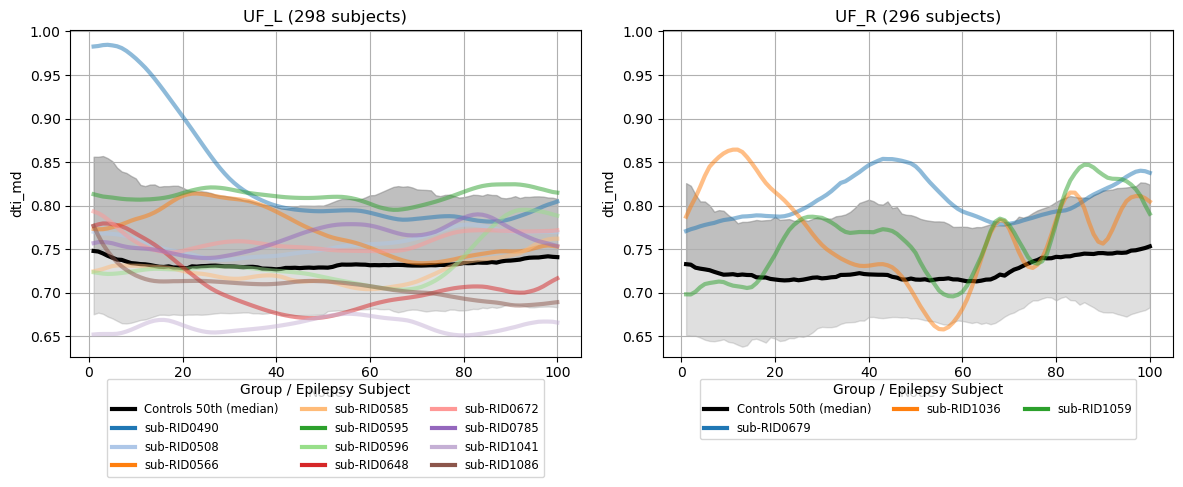

In [20]:
# To plot all epilepsy subjects (default behavior):
plot_tract_profiles(
    tracts=["UF_L", "UF_R"], wm_atlas=wm_atlas, measure=["dti_md"], color_by_group=True, control_centiles=(5,50,95),
    left_mtle=left_mtle, right_mtle=right_mtle
    # left_mtle=left_mtle, right_mtle=right_mtle, sub="sub-EXAMPLE"
)
plt.show()